In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import urllib.request
import matplotlib.pyplot as plt

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [3]:
# hyperparameters
batch_size = 32 # how many independent sequences will we process in parallel
block_size = 128 # the max context length for predictions
max_iters = 20000
eval_interval = 500
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 128
n_head = 8
n_layer = 8
dropout = 0.1 # regularization
grad_clip = 1.0 # gradient clipping for stability
patience = 10 # early stopping: if val loss doesnt improve for 10 evals

In [4]:
torch.manual_seed(1337)

In [5]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
    "../data/input.txt"
    )

('input.txt', <http.client.HTTPMessage at 0x7fd5f8201640>)

In [6]:
# read it in to inspect it
with open('../data/input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [7]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f'Vocab size: {vocab_size}')

Vocab size: 65


In [8]:
# create a mapping from characters to integers
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

In [9]:
# encode the entire text dataset and store it into a torch.tensor
data = torch.tensor(encode(text), dtype=torch.long)

In [10]:
# Split up the data into train and validation sets
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

In [11]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss():
    # compute average loss over eval_iters batches
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


In [12]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x)
        out = wei @ v
        return out

In [13]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [14]:
class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [15]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [16]:
class GPTLanguageModel(nn.Module):
    """GPT-style language model with transformer blocks"""
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=None, top_p=None):
        """Generate text with numerical stability.

        Args:
            idx: Starting token indices (batch_size, seq_len)
            max_new_tokens: Number of tokens to generate
            temperature: Sampling temperature (0.1=deterministic, 1.0=neutral, 2.0=random)
            top_k: Keep only top-k most likely tokens (optional)
            top_p: Nucleus sampling - keep tokens with cumsum prob <= top_p (optional)
        """
        for _ in range(max_new_tokens):
            # Crop to last block_size tokens
            idx_cond = idx[:, -block_size:]

            # Get predictions without computing gradients
            with torch.no_grad():
                logits, _ = self(idx_cond)

            # Get last position logits
            logits = logits[:, -1, :]  # (B, vocab_size)

            # Apply temperature
            if temperature != 1.0:
                logits = logits / temperature

            # Top-k filtering
            if top_k is not None:
                top_k = min(top_k, logits.size(-1))
                v, _ = torch.topk(logits, top_k, dim=-1)
                logits[logits < v[:, [-1]]] = float('-inf')

            # Top-p (nucleus) filtering
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                cumsum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumsum_probs > top_p
                # Keep at least one token
                sorted_indices_to_remove[..., 0] = False
                logits[sorted_indices[sorted_indices_to_remove]] = float('-inf')

            # Apply softmax with numerical stability
            probs = F.softmax(logits, dim=-1)

            # Safety check: if we get NaN/Inf, use uniform distribution
            if torch.isnan(probs).any() or torch.isinf(probs).any():
                print("Warning: NaN/Inf detected in probabilities, using uniform distribution")
                probs = torch.ones_like(logits) / logits.size(-1)

            # Safety check: if all probs are zero, use uniform
            prob_sum = probs.sum(dim=-1, keepdim=True)
            if (prob_sum == 0).any():
                print("Warning: Zero probability sum, using uniform distribution")
                probs = torch.ones_like(logits) / logits.size(-1)

            # Renormalize to ensure valid distribution
            probs = torch.clamp(probs, min=1e-8)
            probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample next token
            try:
                idx_next = torch.multinomial(probs, num_samples=1)
            except RuntimeError as e:
                print(f"Multinomial failed: {e}. Using argmax.")
                idx_next = torch.argmax(probs, dim=-1, keepdim=True)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

# class BigramLanguageModel(nn.Module):

#     def __init__(self):
#         super().__init__()
#         # each token directly reads off the logits for the next token from a lookup table
#         self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
#         self.position_embedding_table = nn.Embedding(block_size, n_embd)
#         self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
#         self.ln_f = nn.LayerNorm(n_embd) # final layer norm
#         self.lm_head = nn.Linear(n_embd, vocab_size)

#     def forward(self, idx, targets=None):
#         B, T = idx.shape

#         # idx and targets are both (B,T) tensor of integers
#         tok_emb = self.token_embedding_table(idx) # (B,T,C)
#         pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
#         x = tok_emb + pos_emb # (B,T,C)
#         x = self.blocks(x) # (B,T,C)
#         x = self.ln_f(x) # (B,T,C)
#         logits = self.lm_head(x) # (B,T,vocab_size)

#         if targets is None:
#             loss = None
#         else:
#             B, T, C = logits.shape
#             logits = logits.view(B*T, C)
#             targets = targets.view(B*T)
#             loss = F.cross_entropy(logits, targets)

#         return logits, loss

#     def generate(self, idx, max_new_tokens):
#         # idx is (B, T) array of indices in the current context
#         for _ in range(max_new_tokens):
#             # crop idx to the last block_size tokens
#             idx_cond = idx[:, -block_size:]
#             # get the predictions
#             logits, loss = self(idx_cond)
#             # focus only on the last time step
#             logits = logits[:, -1, :] # becomes (B, C)
#             # apply softmax to get probabilities
#             probs = F.softmax(logits, dim=-1) # (B, C)
#             # sample from the distribution
#             idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
#             # append sampled index to the running sequence
#             idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
#         return idx


In [17]:
model = GPTLanguageModel().to(device)
m = model
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

1.616449 M parameters


In [18]:
# optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=learning_rate)

In [19]:
# learning rate scheduler (cosine annealing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters)

In [20]:
# training loop with early stopping
best_val_loss = float('inf')
patience_counter = 0

In [21]:
# analytics
train_losses, val_losses = [], []

In [22]:
for iter in range(max_iters):

    # every once in a while, evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        print(f"step {iter:5d} | Train loss {losses['train']:.4f} | Val loss {losses['val']:.4f}", end='')

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            patience_counter = 0
            torch.save(m.state_dict(), 'best_model.pt')
            print(' ✓ (saved)')
        else:
            patience_counter += 1
            print(f' (patience: {patience_counter}/{patience})')
            if patience_counter >= patience:
                print(f"Early stopping at step {iter}.")
                break

    # training step
    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)

    optimizer.step()
    scheduler.step()

step     0 | Train loss 4.3369 | Val loss 4.3383 ✓ (saved)
step   500 | Train loss 1.9607 | Val loss 2.0354 ✓ (saved)
step  1000 | Train loss 1.6559 | Val loss 1.8103 ✓ (saved)
step  1500 | Train loss 1.5257 | Val loss 1.7069 ✓ (saved)
step  2000 | Train loss 1.4559 | Val loss 1.6506 ✓ (saved)
step  2500 | Train loss 1.4021 | Val loss 1.6103 ✓ (saved)
step  3000 | Train loss 1.3672 | Val loss 1.5942 ✓ (saved)
step  3500 | Train loss 1.3413 | Val loss 1.5629 ✓ (saved)
step  4000 | Train loss 1.3115 | Val loss 1.5527 ✓ (saved)
step  4500 | Train loss 1.2964 | Val loss 1.5386 ✓ (saved)
step  5000 | Train loss 1.2788 | Val loss 1.5403 (patience: 1/10)
step  5500 | Train loss 1.2647 | Val loss 1.5221 ✓ (saved)
step  6000 | Train loss 1.2528 | Val loss 1.5194 ✓ (saved)
step  6500 | Train loss 1.2324 | Val loss 1.5166 ✓ (saved)
step  7000 | Train loss 1.2202 | Val loss 1.5063 ✓ (saved)
step  7500 | Train loss 1.2031 | Val loss 1.5267 (patience: 1/10)
step  8000 | Train loss 1.1960 | Val loss 

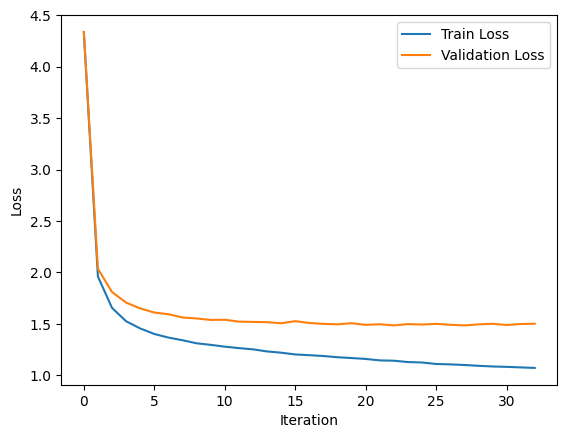

In [23]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
# load the best model
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

GPTLanguageModel(
  (token_embedding_table): Embedding(65, 128)
  (position_embedding_table): Embedding(128, 128)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=128, out_features=16, bias=False)
            (query): Linear(in_features=128, out_features=16, bias=False)
            (value): Linear(in_features=128, out_features=16, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedFoward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=Tr

In [25]:
# generate test with temperature control
print("\n" + "="*80)
print("GENERATED TEST (temperature=0.85, simple sampling):")
print("="*80)


GENERATED TEST (temperature=0.85, simple sampling):


In [26]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=1500, temperature=0.85)
print(decode(generated[0].tolist()))


And you fight make me bassad worse,
Even his new than an old Jack to the Duke of York,
And mine honour.

KING RICHARD II:
It were the queen of the heavens to do thine.

YORK:
He, sir, my wife's child.

QUEEN MARGARET:
O, she had had meet some the nobility
Thou art one to see the gates for my Marchiop,
Incension worst thy sense to be care.

KING EDWARD IV:
And I am as vain, as I quickly the day.

JULIET:
Your grace more kingdoms to be confess
As of words as happy soon by and ill;
I am reconceed of your honour, and your mistress.

KING RICHARD II:
So, sweet slain; and see I in such a prince?

JULIET:
Consul, sir, he prays your son, in place
From change are rival to one sleep.

First Keeper:
Your love is done: 'twas nothing; I have said
As I three dead and lucky in these beauty
Of his son, that he dost valour of disease;
That Warwick's demandment prison, and art
A man thou hast been a tender murderer;
His words are victory of breaths the people,
Unto my repetition and unto his noised for

In [29]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=1000, temperature=0.85)
print(decode(generated[0].tolist()))


The Duke of Hereford, and my grace hands to your highness,
Speak and lowly drink'd Warwick here with your inward.

RICHARD:
Be so shall be a statute. Angelo, brother,
And from the nobility kingdoms of lambs.
What news do I meet his cause, when means she
I have learn'd to the good to chop to this policy?
What man are they are quiet at I true,
And stir, God forbids that be known the daughter's love:
Then great I had no happy more hence in hand,
That left her prove a sentence of the truth:
Where the boy, they are sure; therefore, being gentlemen;
O, not a remiss regiment.

MENENIUS:
The advertnous king,
Nor any more spring than than holy good father.
The last is courted and all tells: he's provided,
Look to fair visitation.

LUCIO:
Having spent! Why, there would nothing his grave,
When it be a weary to be the world and with glass,
that yat show'd the encounter of his royal place,
And he will not hence had a faulty take
Redewick your brother; and your honour mother
With your highness pres